# scikit-learn — the parts you'll actually use

> A complete tabular-ML workflow: load → explore → split → train → evaluate
> → visualise → diagnose. We start with a single feature, then add more,
> and see exactly what changes when we do.

scikit-learn is enormous, but the day-to-day API is tiny. This tutorial
walks the entire workflow on the **UCI auto-MPG dataset** — 392 cars from
the 1970s and 80s, with weight, horsepower, cylinders, and a target of
miles-per-gallon — and ends with the diagnostics that turn a fit into an
honest answer.

## 1. Setup and data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
np.random.seed(0)

df = sns.load_dataset('mpg').dropna().rename(columns={
    'mpg': 'MPG', 'weight': 'Weight', 'horsepower': 'Horsepower',
    'cylinders': 'Cylinders', 'displacement': 'Displacement',
    'acceleration': 'Acceleration', 'model_year': 'ModelYear', 'origin': 'Origin'})
print(f'{len(df)} cars, {df.shape[1]} columns')
df.head()

392 cars, 9 columns


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,ModelYear,Origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 2. Explore — before you fit anything

The single most underused step in beginner ML is **looking at the data
first**. Quick summary stats and a correlation matrix tell you a lot
about which features are predictive.

In [2]:
df[['MPG', 'Weight', 'Horsepower', 'Cylinders',
    'Displacement', 'Acceleration']].describe().round(2)

,MPG,Weight,Horsepower,Cylinders,Displacement,Acceleration
count,392.00,392.00,392.00,392.00,392.00,392.00
mean,23.45,2977.58,104.47,5.47,194.41,15.54
std,7.81,849.40,38.49,1.71,104.64,2.76
min,9.00,1613.00,46.00,3.00,68.00,8.00
25%,17.00,2225.25,75.00,4.00,105.00,13.78
50%,22.75,2803.50,93.50,4.00,151.00,15.50
75%,29.00,3614.75,126.00,8.00,275.75,17.02
max,46.60,5140.00,230.00,8.00,455.00,24.80


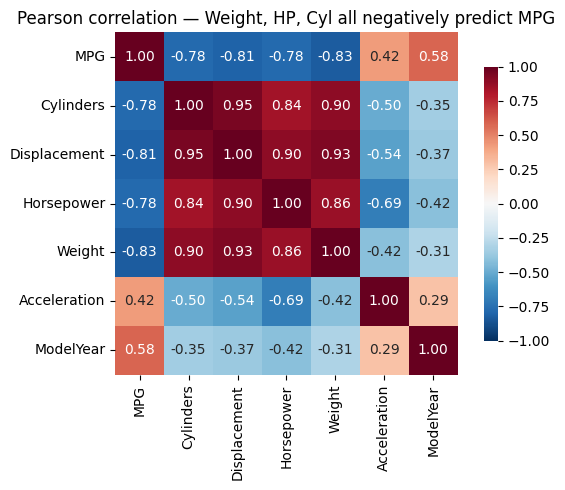

In [3]:
num = ['MPG', 'Cylinders', 'Displacement', 'Horsepower',
       'Weight', 'Acceleration', 'ModelYear']
plt.figure(figsize=(6.5, 5))
sns.heatmap(df[num].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws=dict(shrink=0.8))
plt.title('Pearson correlation — Weight, HP, Cyl all negatively predict MPG')
plt.tight_layout(); plt.show()

## 3. The train / test split

**Never train on the data you evaluate on.** We hold out 20 % of rows
as a test set the model never sees during fitting. `random_state=0`
makes the split reproducible — always set it during development.

In [4]:
X = df[['Weight']]
y = df['MPG']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(f'train: {len(X_train):>3}   test: {len(X_test):>3}')

train: 313   test:  79


## 4. The single-feature model — Weight → MPG

Three lines and you have a linear regressor in sklearn. The pattern is
the same for every model in the library: instantiate, `.fit`, `.predict`.

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f'slope     = {model.coef_[0]:.4f} MPG per pound of weight')
print(f'intercept = {model.intercept_:.2f} MPG (extrapolated weight=0, not meaningful)')

slope     = -0.0077 MPG per pound of weight
intercept = 46.43 MPG (extrapolated weight=0, not meaningful)


## 5. Three numbers every regression model gets

| metric | formula | what it means |
|---|---|---|
| **MSE** | mean of (y − ŷ)² | average squared error; penalises big mistakes |
| **RMSE** | √MSE | same units as y; "typical error" |
| **R²** | 1 − SS_res / SS_tot | fraction of variance the model explains; 1 perfect, 0 useless |

In [6]:
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
print(f'MSE  = {mse:.3f}')
print(f'RMSE = {rmse:.3f} MPG  (typical error)')
print(f'R²   = {r2:.3f}     ({r2*100:.1f}% of variance explained)')

MSE  = 19.985
RMSE = 4.470 MPG  (typical error)
R²   = 0.678     (67.8% of variance explained)


## 6. Visualise the fit — two plots that always belong together

The first plot shows the regression line over the data. The second plot
('actual vs predicted') is more honest: every point should lie close to
the diagonal. **Systematic deviations from the diagonal are the first
sign of a bad model.**

/Users/allamaprabhuani/miniconda3/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


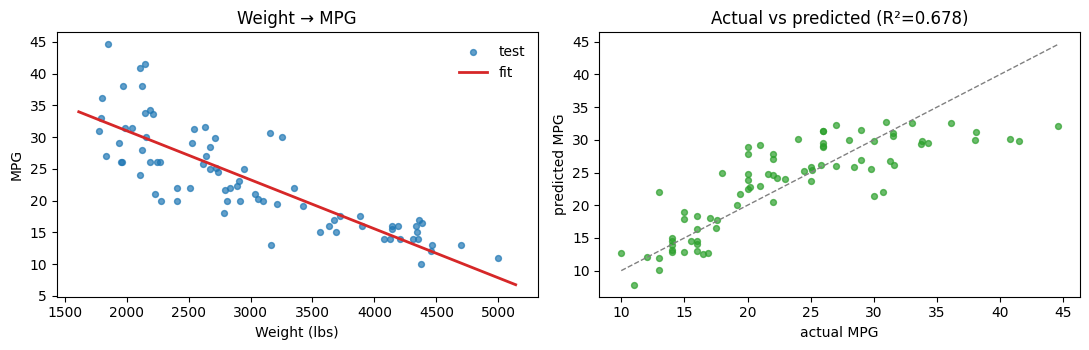

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].scatter(X_test, y_test, s=18, alpha=0.7, color='#1f77b4', label='test')
xs = np.linspace(X['Weight'].min(), X['Weight'].max(), 100).reshape(-1, 1)
axes[0].plot(xs, model.predict(xs), color='#d62728', lw=2, label='fit')
axes[0].set_xlabel('Weight (lbs)'); axes[0].set_ylabel('MPG')
axes[0].set_title('Weight → MPG'); axes[0].legend(frameon=False)

axes[1].scatter(y_test, y_pred, s=18, alpha=0.7, color='#2ca02c')
lo, hi = y_test.min(), y_test.max()
axes[1].plot([lo, hi], [lo, hi], '--', color='gray', lw=1)
axes[1].set_xlabel('actual MPG'); axes[1].set_ylabel('predicted MPG')
axes[1].set_title(f'Actual vs predicted (R²={r2:.3f})')
plt.tight_layout(); plt.show()

## 7. Multi-feature regression — add more predictors

A single feature is rarely enough. Same workflow, more columns in X.

In [8]:
X_multi = df[['Weight', 'Horsepower', 'Cylinders']]
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=0)

multi = LinearRegression().fit(Xm_train, ym_train)
ym_pred = multi.predict(Xm_test)

mse_m  = mean_squared_error(ym_test, ym_pred)
rmse_m = np.sqrt(mse_m)
r2_m   = r2_score(ym_test, ym_pred)
print(f'multivariate model:')
print(f'  RMSE = {rmse_m:.3f}  (single-feature was {rmse:.3f})')
print(f'  R²   = {r2_m:.3f}  (single-feature was {r2:.3f})')

print('\nlearned coefficients:')
for name, c in zip(X_multi.columns, multi.coef_):
    print(f'  {name:>12s}:  {c:+.5f}')

multivariate model:
  RMSE = 4.314  (single-feature was 4.470)
  R²   = 0.701  (single-feature was 0.678)

learned coefficients:
        Weight:  -0.00562
    Horsepower:  -0.04089
     Cylinders:  -0.29259


## 8. Read the coefficients carefully

Each coefficient is the predicted change in MPG for a **one-unit
increase in that feature, holding all others fixed**. But "all others
fixed" rarely makes physical sense — a heavier car almost always has
more horsepower, so the coefficient on Weight in the multivariate fit
is *conditional* on holding HP constant. Always check feature
correlations before reading coefficients literally.

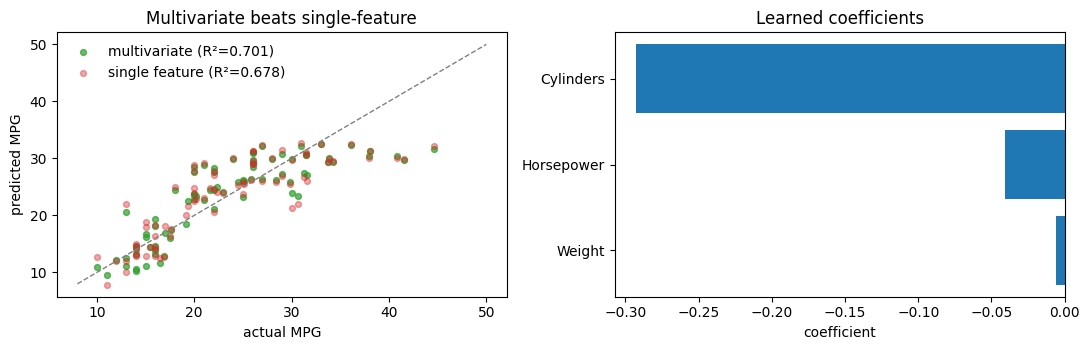

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].scatter(ym_test, ym_pred, s=18, alpha=0.7, color='#2ca02c',
                 label=f'multivariate (R²={r2_m:.3f})')
axes[0].scatter(y_test, y_pred, s=18, alpha=0.4, color='#d62728',
                 label=f'single feature (R²={r2:.3f})')
lo, hi = 8, 50
axes[0].plot([lo, hi], [lo, hi], '--', color='gray', lw=1)
axes[0].set_xlabel('actual MPG'); axes[0].set_ylabel('predicted MPG')
axes[0].set_title('Multivariate beats single-feature')
axes[0].legend(frameon=False)

coefs = pd.Series(multi.coef_, index=X_multi.columns)
axes[1].barh(coefs.index, coefs.values,
              color=['#1f77b4' if c < 0 else '#d62728' for c in coefs.values])
axes[1].axvline(0, color='#444', lw=0.5)
axes[1].set_xlabel('coefficient'); axes[1].set_title('Learned coefficients')
plt.tight_layout(); plt.show()

## 9. Overfitting and underfitting in one figure

A linear model with one feature cannot capture curvature — it
*underfits*. A polynomial regression with too many terms memorises noise
— it *overfits*. The right answer is in the middle. This is the
**bias-variance trade-off**, and it shows up in every ML problem.

Below: three models on the same noisy synthetic curve. The degree-1
model is too rigid; the degree-18 model is too wiggly; the degree-4
model gets it right.

/Users/allamaprabhuani/miniconda3/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/allamaprabhuani/miniconda3/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/allamaprabhuani/miniconda3/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


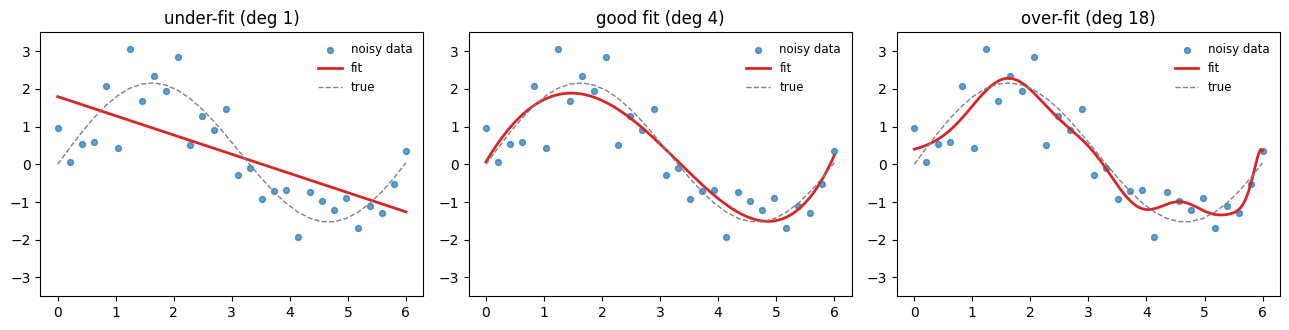

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(1)
x_c = np.linspace(0, 6, 30)
y_c = 2 * np.sin(x_c) + 0.1 * x_c
y_n = y_c + 0.6 * np.random.randn(len(x_c))
xgrid = np.linspace(0, 6, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, deg, title in zip(axes, [1, 4, 18],
                           ['under-fit (deg 1)', 'good fit (deg 4)',
                            'over-fit (deg 18)']):
    p = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    p.fit(x_c.reshape(-1, 1), y_n)
    ax.scatter(x_c, y_n, s=18, alpha=0.7, color='#1f77b4', label='noisy data')
    ax.plot(xgrid, p.predict(xgrid), color='#d62728', lw=2, label='fit')
    ax.plot(x_c, y_c, '--', color='gray', lw=1, label='true')
    ax.set_title(title); ax.set_ylim(-3.5, 3.5)
    ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

## 10. Exercises

These are open-ended; try them on the auto-MPG data above.

1. **Single-variable with `Horsepower`.** Repeat §4-§6 with `Horsepower`
   instead of `Weight`. Which feature predicts MPG better on its own?
2. **Multivariate with `Weight` + `Cylinders` only.** How does dropping
   `Horsepower` change RMSE and R²?
3. **Standardise the features** (use `sklearn.preprocessing.StandardScaler`)
   before fitting. The R² should be identical for a linear model — *why*?
   And what would change if we used Ridge regression instead?
4. **Add `ModelYear`** to the multivariate model. Does it help? Why might
   this feature behave differently from the engine specs?

## What you've built

- A complete sklearn workflow on a real dataset: load → explore → split →
  fit → evaluate → visualise.
- Two regression models (single-feature, multivariate) and the three
  metrics (MSE, RMSE, R²) every regression result ships with.
- An intuition for what coefficients mean, when they don't mean what
  they look like, and why "actual vs predicted" is the honest diagnostic.
- A visual feel for the bias-variance trade-off.

**Next:** [`03 — Introduction to Neural Networks`](/tutorials/03-neural-networks-intro/)
— what changes when the model is a network and the framework is PyTorch.